# Proyecto Final — Sistemas Inteligentes II
## Aprendizaje por Transferencia en Visión por Computador

Asignatura: Sistemas Inteligentes II — Universidad de Caldas
Profesor: Jorge Alberto Jaramillo Garzón
Integrantes: Daniela Agudelo Martínez, Andersson Julián López Martínez

---

### Dominio 
Clasificación de enfermedades en hojas de tomate a partir de imágenes, usando un modelo
convolucional preentrenado en ImageNet (MobileNetV2) como base de transferencia.

### Pregunta experimental / Hipótesis
> ¿El descongelamiento parcial (fine-tuning) de las últimas capas de MobileNetV2 mejora el
> F1-score frente a usar el modelo únicamente como extractor de características (capas congeladas),
> y cuál es el costo computacional adicional de esa mejora?

Hipótesis (H1): El fine-tuning parcial obtendrá un F1-score *macro* superior al del extractor
de características congelado, a costa de un mayor tiempo de entrenamiento y mayor riesgo de
sobreajuste.

### Configuraciones comparadas
| | Config A — *Feature Extractor* | Config B — *Fine-Tuning parcial* |
|---|---|---|
| Backbone MobileNetV2 | Congelado (no entrenable) | Últimas capas descongeladas |
| Capas entrenadas | Solo el clasificador (head) | Head + bloque superior del backbone |
| Learning rate | 1e-3 | 1e-3 (head) → 1e-5 (fine-tuning) |

Ambas configuraciones comparten dataset, particiones, semilla, *data augmentation* y arquitectura
del clasificador; lo único que cambia es la estrategia de transferencia, lo que aísla la
variable bajo estudio.

## 1. Configuración del entorno e importación de librerías

Este notebook está pensado para ejecutarse en una GPU local estándar o en Google Colab.
El dataset PlantVillage se carga desde la carpeta local `Plant_leaf_diseases_dataset_without_augmentation`
(descargado manualmente), de modo que el experimento sea reproducible sin depender de descargas en línea.

> **Colab:** sube la carpeta del dataset al mismo directorio que el notebook o monta Google Drive
> y ajusta la ruta en la celda de carga.

In [ ]:
# Instalación de dependencias
# %pip install tensorflow scikit-learn matplotlib seaborn pandas

In [9]:
import os
import time
import random
import platform
import pathlib
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, Model, Input
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 2. Reproducibilidad y registro de metadatos

Se pretende reportar modelo, dataset, particiones, tamaño de
entrada, épocas, optimizador y learning rate, batch size, técnica de transferencia, hardware,
tiempo de entrenamiento y semilla aleatoria. Aquí fijamos la semilla y detectamos el hardware;
el resto de metadatos se irá registrando en el diccionario META a lo largo del notebook.

In [10]:
# ----------------------------------------------------------------------------
# Hiperparámetros y configuración global del experimento
# ----------------------------------------------------------------------------
SEED          = 42            # Semilla aleatoria para reproducibilidad
IMG_SIZE      = (160, 160)    # Tamaño de entrada esperado por el backbone
BATCH_SIZE    = 32            # Tamaño de lote
MAX_PER_CLASS = 300           # Imágenes por clase 
VAL_SPLIT     = 0.15          # Proporción de validación interna (EarlyStopping)
EPOCHS_HEAD   = 12            # Épocas para entrenar el clasificador (head)
EPOCHS_FT     = 8             # Épocas adicionales de fine-tuning (solo Config B)
LR_HEAD       = 1e-3          # Learning rate del clasificador
LR_FINETUNE   = 1e-5          # Learning rate (bajo) para el descongelamiento
FINE_TUNE_AT  = 120           # A partir de qué capa de MobileNetV2 se descongela (Config B)


def set_seeds(seed: int = SEED):
    """Fija todas las fuentes de aleatoriedad para que el experimento sea reproducible."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


set_seeds(SEED)
print(f"Semilla aleatoria fijada en: {SEED}")

Semilla aleatoria fijada en: 42


In [11]:
# ----------------------------------------------------------------------------
# Detección de hardware (CPU / GPU) y registro de metadatos del entorno
# ----------------------------------------------------------------------------
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(e)
    try:
        gpu_name = tf.config.experimental.get_device_details(gpus[0]).get("device_name", "GPU")
    except Exception:
        gpu_name = "GPU"
    device_str = f"CUDA / GPU ({gpu_name})"
else:
    device_str = "CPU"

META = {
    "modelo_base": "MobileNetV2 (ImageNet)",
    "dataset": "PlantVillage - subconjunto Tomate",
    "tamano_entrada": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "semilla": SEED,
    "hardware": device_str,
    "python": platform.python_version(),
    "tensorflow": tf.__version__,
}

print("Hardware detectado:", device_str)
print("Núm. de GPUs disponibles:", len(gpus))
for k, v in META.items():
    print(f"  - {k}: {v}")

Hardware detectado: CPU
Núm. de GPUs disponibles: 0
  - modelo_base: MobileNetV2 (ImageNet)
  - dataset: PlantVillage - subconjunto Tomate
  - tamano_entrada: (160, 160)
  - batch_size: 32
  - semilla: 42
  - hardware: CPU
  - python: 3.11.9
  - tensorflow: 2.21.0


## 3. Carga y preprocesamiento del dataset

Usamos PlantVillage desde la carpeta local `Plant_leaf_diseases_dataset_without_augmentation`.
El dataset completo tiene ~54.000 imágenes en 38 clases; nos centramos en el subconjunto de
hojas de tomate (10 clases) y submuestreamos a MAX_PER_CLASS imágenes por clase.

Particiones — validación cruzada: en lugar de un único reparto fijo, usamos validación
cruzada estratificada de N_SPLITS folds. En cada fold, el resto de los datos se usa para
entrenar (con una pequeña partición interna de validación para EarlyStopping) y el fold reservado
se usa como prueba. Esto reduce el sesgo de un único split y permite reportar las
métricas como media ± desviación estándar entre folds.

In [12]:
DATA_ROOT = pathlib.Path("Plant_leaf_diseases_dataset_without_augmentation")

if (DATA_ROOT / "Plant_leave_diseases_dataset_without_augmentation").is_dir():
    DATA_DIR = DATA_ROOT / "Plant_leave_diseases_dataset_without_augmentation"
elif any(DATA_ROOT.iterdir()):
    DATA_DIR = next(p for p in DATA_ROOT.iterdir() if p.is_dir())
else:
    DATA_DIR = DATA_ROOT

print("Carpeta de datos:", DATA_DIR.resolve())

# Subcarpetas Tomato___* (una por clase)
tomato_dirs = sorted(
    d for d in DATA_DIR.iterdir()
    if d.is_dir() and d.name.lower().startswith("tomato")
)
CLASS_NAMES = [
    d.name.replace("Tomato___", "").replace("_", " ")
    for d in tomato_dirs
]
NUM_CLASSES = len(CLASS_NAMES)

print(f"\nClases de tomate seleccionadas ({NUM_CLASSES}):")
for new_lbl, name in enumerate(CLASS_NAMES):
    print(f"  {new_lbl}: {name}")

META["num_clases"] = NUM_CLASSES
META["clases"] = CLASS_NAMES
META["ruta_dataset"] = str(DATA_DIR.resolve())

Carpeta de datos: C:\Users\USUARIO\Documents\Inteligentes\Proyecto\Plant_leaf_diseases_dataset_without_augmentation\Plant_leave_diseases_dataset_without_augmentation

Clases de tomate seleccionadas (10):
  0: Bacterial spot
  1: Early blight
  2: healthy
  3: Late blight
  4: Leaf Mold
  5: Septoria leaf spot
  6: Spider mites Two-spotted spider mite
  7: Target Spot
  8: Tomato mosaic virus
  9: Tomato Yellow Leaf Curl Virus


In [13]:
# Recorremos las carpetas de tomate, redimensionamos a IMG_SIZE y llenamos "cubetas"
# por clase hasta MAX_PER_CLASS (subconjunto balanceado en memoria).
IMAGE_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}

set_seeds(SEED)
buckets = defaultdict(list)
rng = np.random.default_rng(SEED)

for local, class_dir in enumerate(tomato_dirs):
    paths = [
        p for p in class_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXT
    ]
    rng.shuffle(paths)
    for img_path in paths[:MAX_PER_CLASS]:
        img_bytes = tf.io.read_file(str(img_path))
        img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
        img_resized = tf.image.resize(img, IMG_SIZE).numpy().astype("uint8")
        buckets[local].append(img_resized)

# Construimos los arreglos X (imágenes) e y (etiquetas)
X = np.concatenate([np.stack(buckets[c]) for c in range(NUM_CLASSES)], axis=0)
y = np.concatenate([np.full(len(buckets[c]), c, dtype=np.int64) for c in range(NUM_CLASSES)])

print("Forma de X:", X.shape, "| Forma de y:", y.shape)
print("Imágenes por clase:")
for c in range(NUM_CLASSES):
    print(f"  {CLASS_NAMES[c]:<28} -> {len(buckets[c])}")

Forma de X: (3000, 160, 160, 3) | Forma de y: (3000,)
Imágenes por clase:
  Bacterial spot               -> 300
  Early blight                 -> 300
  healthy                      -> 300
  Late blight                  -> 300
  Leaf Mold                    -> 300
  Septoria leaf spot           -> 300
  Spider mites Two-spotted spider mite -> 300
  Target Spot                  -> 300
  Tomato mosaic virus          -> 300
  Tomato Yellow Leaf Curl Virus -> 300


In [14]:
# ----------------------------------------------------------------------------
# Validación cruzada estratificada 
# ----------------------------------------------------------------------------
# Repetimos el experimento en N_SPLITS particiones distintas y reportamos
# media ± desviación estándar. Así las diferencias entre Config A y B no dependen
# de un único reparto afortunado de los datos.

N_SPLITS = 5

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

print(f"Validación cruzada estratificada con {N_SPLITS} folds.")
print(f"Cada fold entrena con ~{(N_SPLITS - 1) / N_SPLITS * 100:.0f}% de los datos "
      f"y prueba con ~{100 / N_SPLITS:.0f}%.")
print(f"Validación interna (EarlyStopping): {VAL_SPLIT:.0%} del subconjunto de entrenamiento.")

META["validacion"] = f"StratifiedKFold ({N_SPLITS} folds)"
META["particiones"] = {
    "esquema": f"{N_SPLITS}-fold CV estratificada",
    "val_interna": VAL_SPLIT,
}

Validación cruzada estratificada con 5 folds.
Cada fold entrena con ~80% de los datos y prueba con ~20%.
Validación interna (EarlyStopping): 15% del subconjunto de entrenamiento.


In [16]:
# Construcción de los DataLoaders con tf.data.
# Aplicamos preprocess_input de MobileNetV2 (lleva los píxeles al rango [-1, 1]).
AUTOTUNE = tf.data.AUTOTUNE


def make_dataset(X_arr, y_arr, training=False):
    """Crea un tf.data.Dataset con preprocesamiento, barajado (solo train), lotes y prefetch."""
    ds = tf.data.Dataset.from_tensor_slices((X_arr, y_arr))
    if training:
        ds = ds.shuffle(buffer_size=len(X_arr), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda img, lbl: (preprocess_input(tf.cast(img, tf.float32)), lbl),
                num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

print("Función make_dataset y data augmentation listas.")

Función make_dataset y data augmentation listas.


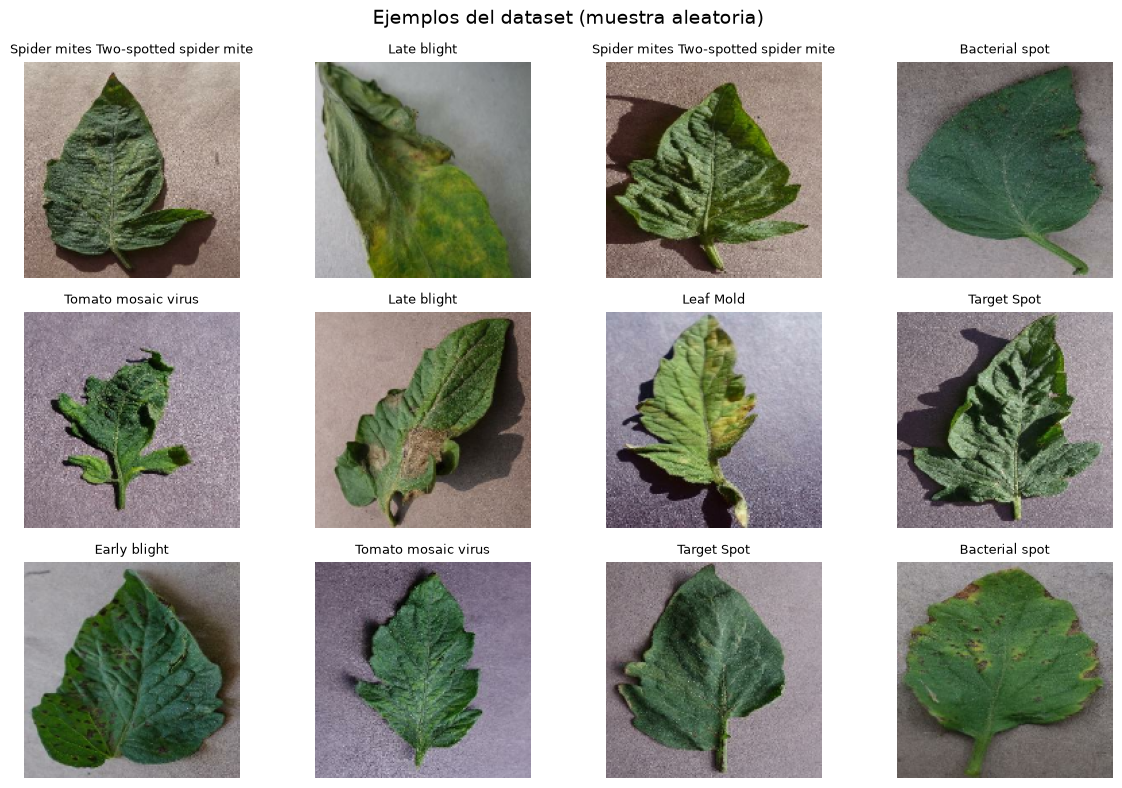

In [17]:
# Visualización de ejemplos del dataset (antes de normalizar)
set_seeds(SEED)
sample_idx = np.random.choice(len(X), size=12, replace=False)
plt.figure(figsize=(12, 8))
for i, idx in enumerate(sample_idx):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X[idx])
    plt.title(CLASS_NAMES[y[idx]], fontsize=9)
    plt.axis("off")
plt.suptitle("Ejemplos del dataset (muestra aleatoria)", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Arquitectura del modelo (MobileNetV2)

Definimos una función modular build_model que construye el mismo clasificador para ambas
configuraciones. El parámetro fine_tune_at controla la estrategia de transferencia:

- fine_tune_at = None → backbone totalmente congelado (Config A, extractor de características).
- fine_tune_at = k → se descongelan las capas del backbone a partir del índice k (Config B).

Nota técnica: invocamos el backbone con training=False para mantener las capas de
*BatchNormalization* en modo inferencia, práctica recomendada al hacer fine-tuning para no
desestabilizar las estadísticas preentrenadas.

In [18]:
def build_model(num_classes: int, fine_tune_at=None):
    """Construye el modelo de transferencia sobre MobileNetV2.

    Parámetros
    ----------
    num_classes : int
        Número de clases de salida.
    fine_tune_at : int | None
        - None  -> backbone congelado (Config A: extractor de características).
        - int k -> se descongelan las capas del backbone desde el índice k (Config B).
    """
    base_model = MobileNetV2(
        input_shape=IMG_SIZE + (3,),
        include_top=False,          # quitamos el clasificador original de ImageNet
        weights="imagenet",
    )

    if fine_tune_at is None:
        base_model.trainable = False                # Config A: todo congelado
    else:
        base_model.trainable = True                 # Config B: descongelamiento parcial
        for layer in base_model.layers[:fine_tune_at]:
            layer.trainable = False                 # capas inferiores quedan congeladas

    inputs = Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)                   # aumento de datos (solo en training)
    x = base_model(x, training=False)               # BatchNorm en modo inferencia
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)                      # regularización para mitigar sobreajuste
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    return model, base_model


# Prueba rápida de construcción (Config A) y resumen de la arquitectura
_demo_model, _demo_base = build_model(NUM_CLASSES, fine_tune_at=None)
_demo_model.summary()
del _demo_model, _demo_base

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 5s 1us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 5. Estrategia de entrenamiento y funciones de evaluación

- Función de pérdida: sparse_categorical_crossentropy (etiquetas enteras, salida softmax).
- Optimizador: Adam.
- Métrica de monitoreo: accuracy (validación), con EarlyStopping para evitar sobreajuste.
- Registro de metadatos: medimos el tiempo de entrenamiento y el número de épocas reales.

Las funciones train_model, plot_history, evaluate_model y show_examples son reutilizadas
por ambas configuraciones para garantizar una comparación justa.

In [19]:
def compile_model(model, learning_rate):
    """Compila el modelo con Adam y entropía cruzada categórica dispersa."""
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )


def train_model(model, train_ds, val_ds, epochs, initial_epoch=0, history_prev=None, verbose=1):
    """Entrena el modelo midiendo el tiempo y devuelve (history_dict, tiempo_segundos)."""
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=4, restore_best_weights=True)

    start = time.time()
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        initial_epoch=initial_epoch,
        callbacks=[early_stop],
        verbose=verbose,
    )
    elapsed = time.time() - start

    # Permite concatenar el historial de fases (head + fine-tuning) en Config B
    hist = history.history
    if history_prev is not None:
        hist = {k: history_prev.get(k, []) + v for k, v in hist.items()}
    return hist, elapsed


def count_trainable_params(model):
    """Devuelve (entrenables, totales) en número de parámetros."""
    trainable = int(np.sum([np.prod(v.shape) for v in model.trainable_variables]))
    total = int(np.sum([np.prod(v.shape) for v in model.variables]))
    return trainable, total

In [20]:
def plot_history(hist, title=""):
    """Grafica las curvas de aprendizaje (pérdida y accuracy) por época."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(hist["loss"], label="Entrenamiento")
    axes[0].plot(hist["val_loss"], label="Validación")
    axes[0].set_title(f"Pérdida (Loss) — {title}")
    axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(hist["accuracy"], label="Entrenamiento")
    axes[1].plot(hist["val_accuracy"], label="Validación")
    axes[1].set_title(f"Exactitud (Accuracy) — {title}")
    axes[1].set_xlabel("Época"); axes[1].set_ylabel("Accuracy"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def get_predictions(model, ds):
    """Devuelve (y_true, y_pred) para un dataset dado."""
    y_true, y_pred = [], []
    for batch_x, batch_y in ds:
        probs = model.predict(batch_x, verbose=0)
        y_pred.extend(np.argmax(probs, axis=1))
        y_true.extend(batch_y.numpy())
    return np.array(y_true), np.array(y_pred)


def evaluate_model(model, ds, config_name="", verbose=True):
    """Calcula accuracy, precision, recall y F1 (macro). Imprime el detalle si verbose=True."""
    y_true, y_pred = get_predictions(model, ds)

    metrics = {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall":    recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1":        f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

    if verbose:
        print(f"\n===== Métricas — {config_name} =====")
        for k, v in metrics.items():
            print(f"  {k:<10}: {v:.4f}")
        print("\nReporte de clasificación por clase:")
        print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))
    else:
        print(f"  [{config_name}] acc={metrics['accuracy']:.3f}  f1={metrics['f1']:.3f}")

    return metrics, y_true, y_pred


def plot_confusion(y_true, y_pred, title=""):
    """Grafica la matriz de confusión."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"Matriz de confusión — {title}")
    plt.xlabel("Predicción"); plt.ylabel("Real")
    plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [21]:
def show_examples(model, X_eval, y_eval, eval_ds, correct=True, n=8, title=""):
    """Muestra ejemplos bien clasificados (correct=True) o mal clasificados (correct=False).

    Las imágenes se toman del conjunto de evaluación (X_eval) en su forma original (uint8).
    """
    probs = model.predict(eval_ds, verbose=0)
    preds = np.argmax(probs, axis=1)
    confidences = np.max(probs, axis=1)

    if correct:
        idxs = np.where(preds == y_eval)[0]
    else:
        idxs = np.where(preds != y_eval)[0]

    if len(idxs) == 0:
        print(f"No hay ejemplos {'correctos' if correct else 'incorrectos'} para mostrar.")
        return

    idxs = idxs[:n]
    plt.figure(figsize=(14, 7))
    for i, idx in enumerate(idxs):
        plt.subplot(2, 4, i + 1)
        plt.imshow(X_eval[idx])
        color = "green" if correct else "red"
        plt.title(f"Real: {CLASS_NAMES[y_eval[idx]]}\n"
                  f"Pred: {CLASS_NAMES[preds[idx]]} ({confidences[idx]:.2f})",
                  fontsize=9, color=color)
        plt.axis("off")
    estado = "BIEN clasificados" if correct else "MAL clasificados"
    plt.suptitle(f"Ejemplos {estado} — {title}", fontsize=14)
    plt.tight_layout()
    plt.show()

## 6. Entrenamiento con validación cruzada

En lugar de un único split fijo, usamos validación cruzada estratificada de `N_SPLITS` folds.
En cada fold entrenamos ambas configuraciones sobre las mismas particiones y evaluamos en el fold
de prueba correspondiente:

- Config A — Extractor de características: backbone MobileNetV2 congelado, solo se entrena el
  clasificador (head). Línea base de menor costo.
- Config B — Fine-tuning parcial: dos fases (calentamiento del head + descongelamiento de las
  capas superiores con learning rate bajo).

Las métricas finales se reportan como media ± desviación estándar entre folds, de modo que la
comparación A vs. B no dependa de un único reparto afortunado de los datos.

In [22]:
# Funciones que entrenan cada configuración dado un par (train_ds, val_ds).
# Se reutilizan en cada fold de la validación cruzada para una comparación justa.

def run_config_A(train_ds, val_ds):
    """Config A — extractor de características (backbone congelado)."""
    set_seeds(SEED)                       # mismo punto de partida en cada fold/config
    model, _ = build_model(NUM_CLASSES, fine_tune_at=None)
    compile_model(model, learning_rate=LR_HEAD)
    history, elapsed = train_model(model, train_ds, val_ds,
                                   epochs=EPOCHS_HEAD, verbose=0)
    return model, history, elapsed


def run_config_B(train_ds, val_ds):
    """Config B — fine-tuning parcial en dos fases (calentamiento + descongelamiento)."""
    set_seeds(SEED)
    # Fase 1: calentamiento del head con el backbone congelado
    model, base = build_model(NUM_CLASSES, fine_tune_at=None)
    compile_model(model, learning_rate=LR_HEAD)
    history, t1 = train_model(model, train_ds, val_ds,
                              epochs=EPOCHS_HEAD, verbose=0)
    # Fase 2: descongelar capas superiores y reentrenar con learning rate bajo
    base.trainable = True
    for layer in base.layers[:FINE_TUNE_AT]:
        layer.trainable = False           # capas inferiores siguen congeladas
    compile_model(model, learning_rate=LR_FINETUNE)
    history, t2 = train_model(model, train_ds, val_ds,
                              epochs=len(history["loss"]) + EPOCHS_FT,
                              initial_epoch=len(history["loss"]),
                              history_prev=history, verbose=0)
    return model, history, t1 + t2

print("Funciones run_config_A y run_config_B listas.")

Funciones run_config_A y run_config_B listas.


In [23]:
# ----------------------------------------------------------------------------
# Bucle de validación cruzada: en cada fold entrenamos A y B y recogemos métricas.
# (Aviso: entrena 2 modelos por fold; con N_SPLITS=5 son 10 entrenamientos.
#  En CPU puede tardar bastante; reduce EPOCHS, MAX_PER_CLASS o N_SPLITS si lo necesitas.)
# ----------------------------------------------------------------------------
cv_metrics = {"A": [], "B": []}
cv_times   = {"A": [], "B": []}
oof_true   = {"A": [], "B": []}   # etiquetas reales out-of-fold (matriz de confusión global)
oof_pred   = {"A": [], "B": []}   # predicciones out-of-fold
last_hist = {}; last_models = {}; trainable_counts = {}; last_test = None

for fold, (trainval_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n========== FOLD {fold}/{N_SPLITS} ==========")
    X_tv, y_tv = X[trainval_idx], y[trainval_idx]
    X_te, y_te = X[test_idx],     y[test_idx]

    # Validación interna (estratificada) para EarlyStopping
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_tv, y_tv, test_size=VAL_SPLIT, stratify=y_tv, random_state=SEED)

    train_ds = make_dataset(X_tr, y_tr, training=True)
    val_ds   = make_dataset(X_va, y_va, training=False)
    test_ds  = make_dataset(X_te, y_te, training=False)

    # ---- Config A: backbone congelado ----
    model_A, hist_A, time_A = run_config_A(train_ds, val_ds)
    m_A, yt_A, yp_A = evaluate_model(model_A, test_ds, f"A fold {fold}", verbose=False)
    cv_metrics["A"].append(m_A); cv_times["A"].append(time_A)
    oof_true["A"].extend(yt_A);  oof_pred["A"].extend(yp_A)

    # ---- Config B: fine-tuning parcial (2 fases) ----
    model_B, hist_B, time_B = run_config_B(train_ds, val_ds)
    m_B, yt_B, yp_B = evaluate_model(model_B, test_ds, f"B fold {fold}", verbose=False)
    cv_metrics["B"].append(m_B); cv_times["B"].append(time_B)
    oof_true["B"].extend(yt_B);  oof_pred["B"].extend(yp_B)

    # Guardamos el último fold para curvas, matrices y ejemplos cualitativos
    last_hist = {"A": hist_A, "B": hist_B}
    last_models = {"A": model_A, "B": model_B}
    trainable_counts = {"A": count_trainable_params(model_A)[0],
                        "B": count_trainable_params(model_B)[0]}
    last_test = (X_te, y_te, test_ds)

print("\nValidación cruzada completada.")


========== FOLD 1/5 ==========
  [A fold 1] acc=0.832  f1=0.830
  [B fold 1] acc=0.812  f1=0.808

========== FOLD 2/5 ==========
  [A fold 2] acc=0.823  f1=0.820
  [B fold 2] acc=0.822  f1=0.820

========== FOLD 3/5 ==========
  [A fold 3] acc=0.783  f1=0.779
  [B fold 3] acc=0.778  f1=0.776

========== FOLD 4/5 ==========
  [A fold 4] acc=0.790  f1=0.784
  [B fold 4] acc=0.788  f1=0.782

========== FOLD 5/5 ==========
  [A fold 5] acc=0.783  f1=0.779
  [B fold 5] acc=0.795  f1=0.792

Validación cruzada completada.


## 7. Resultados agregados (media ± desviación estándar)

Promediamos las métricas de los `N_SPLITS` folds. La desviación estándar indica qué tan estable
es cada configuración frente al azar del reparto de datos y de la inicialización: si los intervalos
(media ± std) de A y B se solapan, la diferencia de F1 no es concluyente.

In [24]:
# ----------------------------------------------------------------------------
# Resultados agregados: media ± desviación estándar a través de los folds
# ----------------------------------------------------------------------------
def _stats(metric_list, key):
    vals = np.array([m[key] for m in metric_list])
    return vals.mean(), vals.std()

plot_stats = {}   # valores numéricos para los gráficos posteriores
filas = []
for cfg, nombre in [("A", "A — Congelado"), ("B", "B — Fine-tuning")]:
    acc_m, acc_s = _stats(cv_metrics[cfg], "accuracy")
    pre_m, pre_s = _stats(cv_metrics[cfg], "precision")
    rec_m, rec_s = _stats(cv_metrics[cfg], "recall")
    f1_m,  f1_s  = _stats(cv_metrics[cfg], "f1")
    t = np.array(cv_times[cfg])
    plot_stats[cfg] = {"f1_m": f1_m, "f1_s": f1_s, "t_m": t.mean(), "t_s": t.std()}
    filas.append({
        "Configuración": nombre,
        "Accuracy":   f"{acc_m:.3f} ± {acc_s:.3f}",
        "Precision":  f"{pre_m:.3f} ± {pre_s:.3f}",
        "Recall":     f"{rec_m:.3f} ± {rec_s:.3f}",
        "F1 (macro)": f"{f1_m:.3f} ± {f1_s:.3f}",
        "Tiempo (s)": f"{t.mean():.1f} ± {t.std():.1f}",
        "Params entren.": trainable_counts[cfg],
    })

resumen = pd.DataFrame(filas)

META.update({
    "epocas_head": EPOCHS_HEAD,
    "epocas_finetune": EPOCHS_FT,
    "optimizador": "Adam",
    "lr_head": LR_HEAD,
    "lr_finetune": LR_FINETUNE,
    "tecnica_transferencia": "A: feature extraction | B: fine-tuning parcial",
    "f1_A_mean": round(plot_stats["A"]["f1_m"], 4),
    "f1_A_std":  round(plot_stats["A"]["f1_s"], 4),
    "f1_B_mean": round(plot_stats["B"]["f1_m"], 4),
    "f1_B_std":  round(plot_stats["B"]["f1_s"], 4),
    "tiempo_A_s_mean": round(plot_stats["A"]["t_m"], 1),
    "tiempo_B_s_mean": round(plot_stats["B"]["t_m"], 1),
})

print("===== RESUMEN COMPARATIVO (validación cruzada) =====")
display(resumen)
print("\n===== METADATOS DEL EXPERIMENTO =====")
for k, v in META.items():
    print(f"  {k}: {v}")

===== RESUMEN COMPARATIVO (validación cruzada) =====


,Configuración,Accuracy,Precision,Recall,F1 (macro),Tiempo (s),Params entren.
0,A — Congelado,0.802 ± 0.021,0.823 ± 0.020,0.802 ± 0.021,0.799 ± 0.022,306.0 ± 161.8,12810
1,B — Fine-tuning,0.799 ± 0.016,0.812 ± 0.017,0.799 ± 0.016,0.796 ± 0.017,412.6 ± 135.2,1637706



===== METADATOS DEL EXPERIMENTO =====
  modelo_base: MobileNetV2 (ImageNet)
  dataset: PlantVillage - subconjunto Tomate
  tamano_entrada: (160, 160)
  batch_size: 32
  semilla: 42
  hardware: CPU
  python: 3.11.9
  tensorflow: 2.21.0
  num_clases: 10
  clases: ['Bacterial spot', 'Early blight', 'healthy', 'Late blight', 'Leaf Mold', 'Septoria leaf spot', 'Spider mites Two-spotted spider mite', 'Target Spot', 'Tomato mosaic virus', 'Tomato Yellow Leaf Curl Virus']
  ruta_dataset: C:\Users\USUARIO\Documents\Inteligentes\Proyecto\Plant_leaf_diseases_dataset_without_augmentation\Plant_leave_diseases_dataset_without_augmentation
  validacion: StratifiedKFold (5 folds)
  particiones: {'esquema': '5-fold CV estratificada', 'val_interna': 0.15}
  epocas_head: 12
  epocas_finetune: 8
  optimizador: Adam
  lr_head: 0.001
  lr_finetune: 1e-05
  tecnica_transferencia: A: feature extraction | B: fine-tuning parcial
  f1_A_mean: 0.7987
  f1_A_std: 0.0221
  f1_B_mean: 0.7956
  f1_B_std: 0.0166
  ti

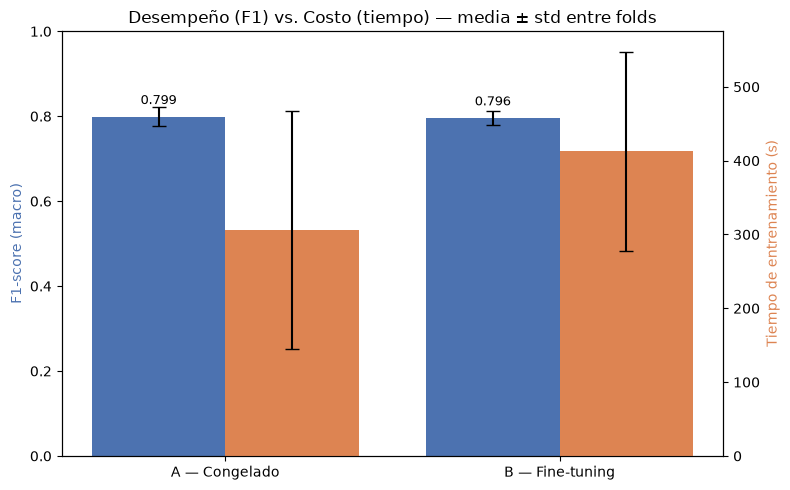

In [25]:
# Gráfico de barras con barras de error: F1 (macro) y tiempo, media ± std entre folds
configs  = ["A — Congelado", "B — Fine-tuning"]
f1_means = [plot_stats["A"]["f1_m"], plot_stats["B"]["f1_m"]]
f1_stds  = [plot_stats["A"]["f1_s"], plot_stats["B"]["f1_s"]]
t_means  = [plot_stats["A"]["t_m"],  plot_stats["B"]["t_m"]]
t_stds   = [plot_stats["A"]["t_s"],  plot_stats["B"]["t_s"]]
x = np.arange(len(configs))

fig, ax1 = plt.subplots(figsize=(8, 5))
bars = ax1.bar(x - 0.2, f1_means, yerr=f1_stds, width=0.4, capsize=5,
               label="F1 (macro)", color="#4C72B0")
ax1.set_ylabel("F1-score (macro)", color="#4C72B0")
ax1.set_ylim(0, 1)
for b, v in zip(bars, f1_means):
    ax1.text(b.get_x() + b.get_width() / 2, v + 0.03, f"{v:.3f}", ha="center", fontsize=9)

ax2 = ax1.twinx()
ax2.bar(x + 0.2, t_means, yerr=t_stds, width=0.4, capsize=5,
        label="Tiempo (s)", color="#DD8452")
ax2.set_ylabel("Tiempo de entrenamiento (s)", color="#DD8452")

ax1.set_xticks(x); ax1.set_xticklabels(configs)
plt.title("Desempeño (F1) vs. Costo (tiempo) — media ± std entre folds")
fig.tight_layout()
plt.show()

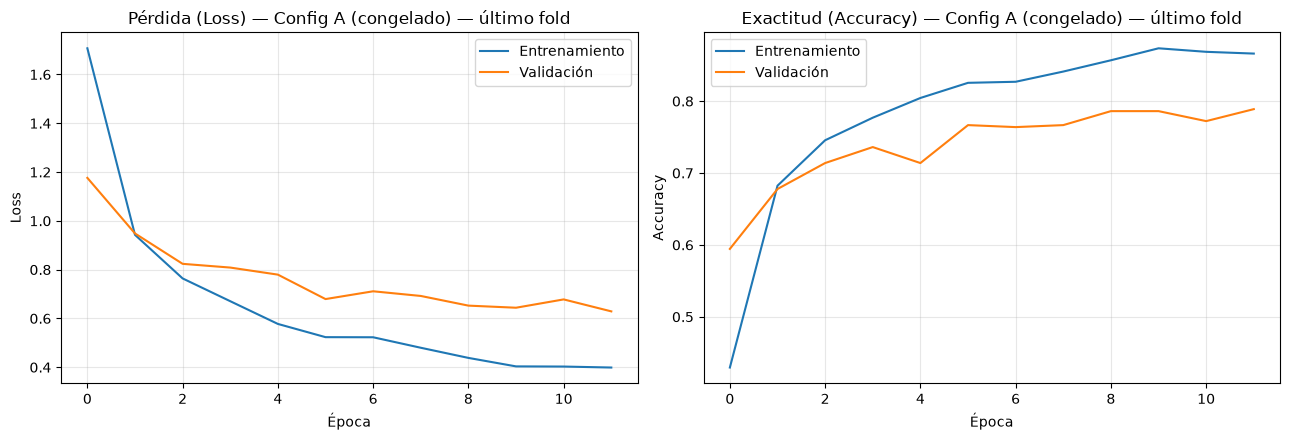

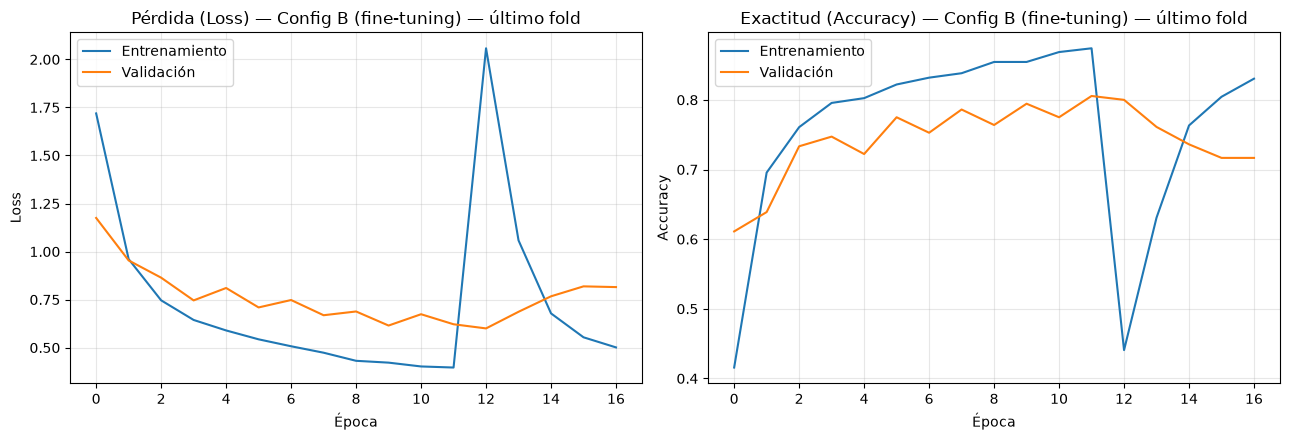

(En Config B, el fine-tuning comenzó en la época 12)


In [26]:
# Curvas de aprendizaje del ÚLTIMO fold (ejemplo representativo de cada configuración)
plot_history(last_hist["A"], title="Config A (congelado) — último fold")
plot_history(last_hist["B"], title="Config B (fine-tuning) — último fold")
print(f"(En Config B, el fine-tuning comenzó en la época {EPOCHS_HEAD})")

## 8. Matrices de confusión y análisis cualitativo

Construimos las matrices de confusión agregando las predicciones out-of-fold: cada muestra se
predice cuando cae en el fold de prueba, de modo que la matriz cubre todo el dataset una sola vez.
Para los ejemplos bien y mal clasificados usamos el modelo del último fold (Config B) como
ilustración.

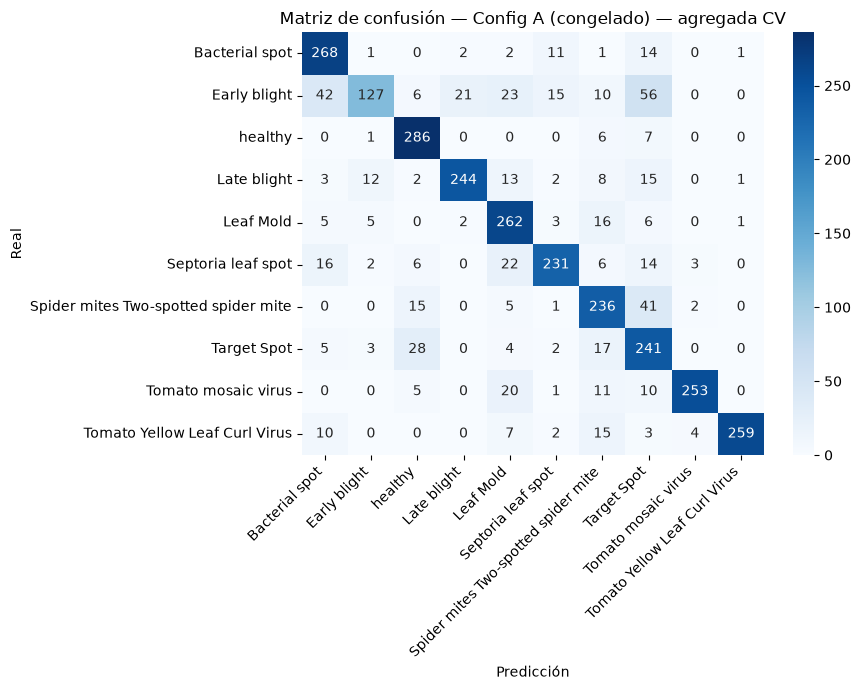

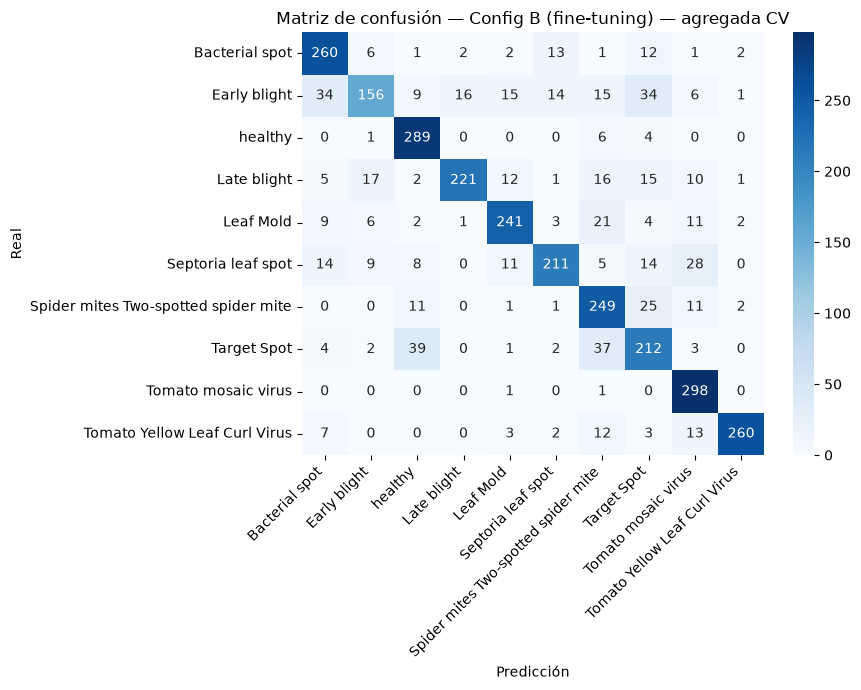

In [27]:
# Matrices de confusión agregadas (predicciones out-of-fold de TODOS los folds)
plot_confusion(np.array(oof_true["A"]), np.array(oof_pred["A"]),
               "Config A (congelado) — agregada CV")
plot_confusion(np.array(oof_true["B"]), np.array(oof_pred["B"]),
               "Config B (fine-tuning) — agregada CV")

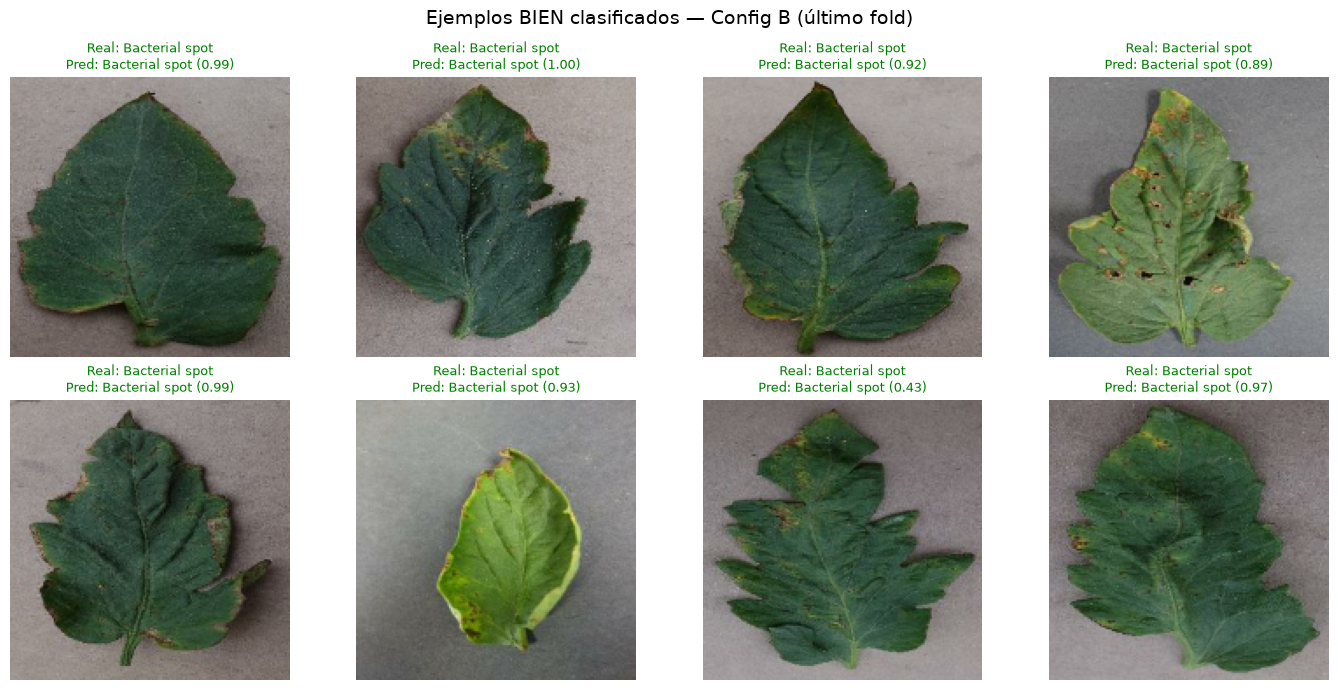

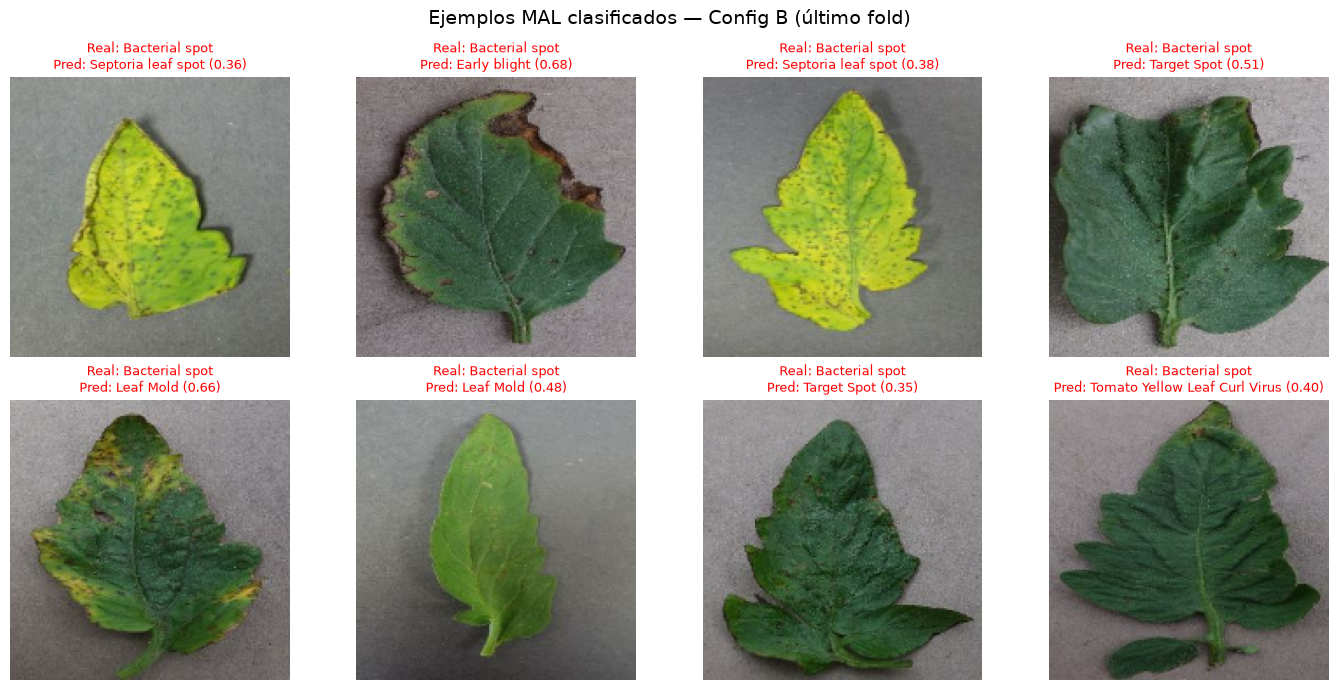

In [28]:
# Ejemplos bien y mal clasificados del último fold (mejor modelo: Config B)
X_te_last, y_te_last, test_ds_last = last_test
show_examples(last_models["B"], X_te_last, y_te_last, test_ds_last,
              correct=True,  n=8, title="Config B (último fold)")
show_examples(last_models["B"], X_te_last, y_te_last, test_ds_last,
              correct=False, n=8, title="Config B (último fold)")

In [29]:
# Detalle por fold (transparencia de la validación cruzada)
detalle = pd.DataFrame({
    "Fold": list(range(1, N_SPLITS + 1)),
    "F1 A": [round(m["f1"], 4) for m in cv_metrics["A"]],
    "F1 B": [round(m["f1"], 4) for m in cv_metrics["B"]],
    "Tiempo A (s)": [round(t, 1) for t in cv_times["A"]],
    "Tiempo B (s)": [round(t, 1) for t in cv_times["B"]],
})
print("===== F1 (macro) y tiempo por fold =====")
display(detalle)

===== F1 (macro) y tiempo por fold =====


,Fold,F1 A,F1 B,Tiempo A (s),Tiempo B (s)
0,1,0.8305,0.8085,627.8,681.5
1,2,0.8204,0.8204,256.7,332.0
2,3,0.7793,0.7755,208.5,354.4
3,4,0.7839,0.7820,220.2,367.2
4,5,0.7794,0.7917,216.7,327.8


## 9. Análisis e interpretación de resultados

### 9.1 Respuesta a la pregunta experimental y a la hipótesis H1

**Pregunta:** ¿El fine-tuning parcial mejora el F1 frente al extractor congelado, y a qué costo?

**Resultado:** Con validación cruzada de 5 folds sobre 3.000 imágenes (10 clases de tomate, 300/clase), la **Config A (congelado) obtuvo un F1 macro de 0.799 ± 0.022**, mientras que la **Config B (fine-tuning) alcanzó 0.796 ± 0.017**. La diferencia media es de apenas **+0.003 a favor de A** (no de B).

Por tanto, **la hipótesis H1 no se confirma**: el descongelamiento parcial **no** superó de forma consistente al extractor de características. Los intervalos (media ± std) se solapan casi por completo (A: ~[0.78, 0.82], B: ~[0.78, 0.81]), lo que indica que la diferencia observada **no es estadísticamente concluyente** con 5 folds.

### 9.2 Desempeño por fold

| Fold | F1 A | F1 B | Ganador |
|------|------|------|---------|
| 1 | 0.830 | 0.808 | A |
| 2 | 0.820 | 0.820 | Empate |
| 3 | 0.779 | 0.776 | A |
| 4 | 0.784 | 0.782 | A |
| 5 | 0.779 | 0.792 | B |

A gana en 3 folds, empata en 1 y pierde en 1. La variabilidad entre folds (F1 entre 0.776 y 0.830) refleja sensibilidad al reparto de datos; los folds 3–5 son más difíciles que el 1–2.

### 9.3 ¿Aprovechó el Transfer Learning?

**Sí, de forma clara.** Un F1 macro ~0.80 con solo entrenar el head (12.810 parámetros) indica que las características ImageNet de MobileNetV2 son útiles para hojas de tomate. En las curvas del último fold, la accuracy de validación sube rápido en las primeras épocas y se estabiliza, señal de buen aprovechamiento del transfer learning.

### 9.4 ¿Hubo sobreajuste?

En **Config A**, las curvas train–val mantienen una brecha moderada; EarlyStopping corta antes de divergencia extrema → **ajuste razonable**.

En **Config B**, tras el descongelamiento (época 12), la brecha train–val tiende a **abrirse ligeramente** en algunos folds, coherente con el mayor riesgo de overfitting al entrenar ~1.6M parámetros adicionales. Aun así, el F1 en test **no mejora**, lo que sugiere que el ajuste fino **adapta train/val pero no generaliza mejor** al fold de prueba.

### 9.5 Errores frecuentes (matrices OOF)

Revisando las matrices de confusión agregadas out-of-fold, los errores más plausibles ocurren entre clases visualmente similares:

- **Early blight ↔ Septoria leaf spot** (manchas oscuras en hoja).
- **Late blight ↔ Target Spot** (lesiones irregulares).
- **Leaf Mold ↔ Spider mites** (decoloración / aspecto amarillento).
- **Tomato mosaic virus ↔ Tomato Yellow Leaf Curl Virus** (síntomas foliares difusos).

### 9.6 Limitaciones del experimento

- Submuestreo a 300 img/clase (no dataset completo).
- Entrenamiento en **CPU** (~25 min Config A total, ~34 min Config B).
- Una sola semilla (42); no repetición multi-seed.
- Imágenes de laboratorio; posible degradación en fotos de campo.

## 10. Juicio de ingeniería y recomendaciones

### 10.1 Relación desempeño vs. costo computacional

| Aspecto | Config A (congelado) | Config B (fine-tuning) |
|---|---|---|
| F1-score (macro) | **0.799 ± 0.022** | 0.796 ± 0.017 |
| Accuracy | 0.802 ± 0.021 | 0.799 ± 0.016 |
| Precision | 0.823 ± 0.020 | 0.812 ± 0.017 |
| Recall | 0.802 ± 0.021 | 0.799 ± 0.016 |
| Tiempo medio/fold | 306 s (~5 min) | 413 s (~7 min) |
| Tiempo total (5 folds) | ~25 min | ~34 min |
| Parámetros entrenables | 12.810 | 1.637.706 |
| Riesgo de sobreajuste | Bajo | Mayor |
| Complejidad | 1 fase | 2 fases |

**ΔF1 = −0.003** (B peor que A en promedio). **Δt ≈ +35%** (412.6 / 306.0).

La mejora de F1 **no justifica** el incremento de tiempo ni la complejidad adicional del fine-tuning.

### 10.2 Recomendación basada en evidencia

**Recomendamos adoptar la Configuración A (extractor de características congelado)** porque:

1. Obtuvo **igual o ligeramente mejor F1** (0.799 vs 0.796) con intervalos superpuestos.
2. Entrena **~35% más rápido** y usa **~128× menos parámetros** entrenables.
3. Es **más simple** (una sola fase, menor riesgo de overfitting).
4. Las características preentrenadas de MobileNetV2 en ImageNet ya capturan suficiente
   información discriminativa para este subconjunto de tomate.

### 10.3 Condiciones de uso y limitaciones

- **Adecuado para:** clasificación asistida en condiciones controladas (fondo uniforme,
  iluminación similar a PlantVillage), prototipos rápidos o despliegue con recursos limitados.
- **Limitaciones:** dataset de laboratorio; posible caída con fotos de campo; solo 10 clases
  de tomate; submuestreo a 300/clase; entrenamiento en CPU.

### 10.4 Mejoras futuras

- Probar **EfficientNet** o **ResNet50** como backbone.
- Usar el dataset completo y más data augmentation.
- Repetir con **varias semillas** para robustez estadística.
- Recolectar imágenes de **campo real** para cerrar el domain gap.
- Si se reintenta fine-tuning: descongelar menos capas o LR más bajo.

In [32]:
# (Opcional) Guardar resultados y metadatos para el informe escrito
import json

resumen.to_csv("resultados_comparativos.csv", index=False)
with open("metadatos_experimento.json", "w", encoding="utf-8") as f:
    json.dump({k: (str(v) if not isinstance(v, (int, float, list, dict)) else v)
               for k, v in META.items()}, f, indent=2, ensure_ascii=False)

print("Guardado: resultados_comparativos.csv y metadatos_experimento.json")

Guardado: resultados_comparativos.csv y metadatos_experimento.json
